In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold
from rdkit import Chem, DataStructs
from rdkit.Chem import PandasTools, AllChem

In [40]:
data = pd.read_csv("dataset-QSAR_90pct_reduced.csv") # tady je ten můj split 90
data.head(5)

,Ambit_InchiKey,Original_Entry_ID,Entrez_ID,Activity_Flag,pXC50,DB,Original_Assay_ID,Tax_ID,Gene_Symbol,Ortholog_Group,SMILES
0,CWYBNSVSYKQGJB-UHFFFAOYNA-N,71541095,6532,A,6.85387,pubchem,727355,9606,SLC6A4,4061,ClC=1C=C(C2CCCCNC2)C=CC1Cl
1,FQDRMHHCWZAXJM-UHFFFAOYNA-N,125558,25553,A,9.98297,pubchem,205028,10116,SLC6A4,4061,O1C=2C=C3CC(N)CC3=CC2OC1
2,QRAWNNQNLQPNIZ-UHFFFAOYNA-N,CHEMBL205229,6532,A,7.54000,chembl20,950695,9606,SLC6A4,4061,N1C=C(CCN)C2=C1C(=CC=C2)F
3,HCFHWXDIZOAUTQ-UHFFFAOYNA-N,CHEMBL6376,25553,A,6.11000,chembl20,201505,10116,SLC6A4,4061,C1(=CC=2OCOC2C=C1C)CC(N)C
4,JBDOSUUXMYMWQH-UHFFFAOYNA-N,CHEMBL1381098,6532,A,5.12000,chembl20,774720,9606,SLC6A4,4061,S=C=NC=1C=2C(C=CC1)=CC=CC2


In [41]:
PandasTools.AddMoleculeColumnToFrame(data,'SMILES','Molecule') #přidána vizualizace
data.head()

,Ambit_InchiKey,Original_Entry_ID,Entrez_ID,Activity_Flag,pXC50,DB,Original_Assay_ID,Tax_ID,Gene_Symbol,Ortholog_Group,SMILES,Molecule
0,CWYBNSVSYKQGJB-UHFFFAOYNA-N,71541095,6532,A,6.85387,pubchem,727355,9606,SLC6A4,4061,ClC=1C=C(C2CCCCNC2)C=CC1Cl,<rdkit.Chem.rdchem.Mol object at 0x7d932d5a87b0>
1,FQDRMHHCWZAXJM-UHFFFAOYNA-N,125558,25553,A,9.98297,pubchem,205028,10116,SLC6A4,4061,O1C=2C=C3CC(N)CC3=CC2OC1,<rdkit.Chem.rdchem.Mol object at 0x7d932d5a8740>
2,QRAWNNQNLQPNIZ-UHFFFAOYNA-N,CHEMBL205229,6532,A,7.54000,chembl20,950695,9606,SLC6A4,4061,N1C=C(CCN)C2=C1C(=CC=C2)F,<rdkit.Chem.rdchem.Mol object at 0x7d932d5a80b0>
3,HCFHWXDIZOAUTQ-UHFFFAOYNA-N,CHEMBL6376,25553,A,6.11000,chembl20,201505,10116,SLC6A4,4061,C1(=CC=2OCOC2C=C1C)CC(N)C,<rdkit.Chem.rdchem.Mol object at 0x7d932d5a8040>
4,JBDOSUUXMYMWQH-UHFFFAOYNA-N,CHEMBL1381098,6532,A,5.12000,chembl20,774720,9606,SLC6A4,4061,S=C=NC=1C=2C(C=CC1)=CC=CC2,<rdkit.Chem.rdchem.Mol object at 0x7d932d5a8120>


[0 0 0 ... 0 0 0]
4096


[14:06:29] DEPRECATION WARNING: please use MorganGenerator


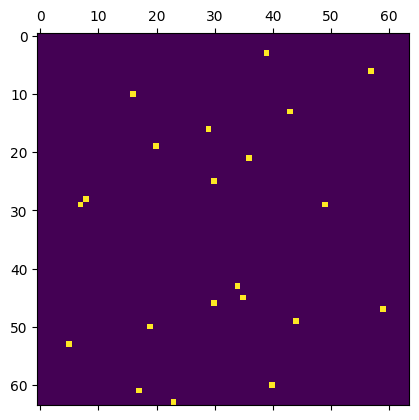

In [42]:
# převádím smiles na barcode a upravuju ho do matice a tu pak vizualizuju
def mol2fp(mol):
    fp = AllChem.GetHashedMorganFingerprint(mol, 2, nBits=4096)
    ar = np.zeros((1,), dtype=np.int8)
    DataStructs.ConvertToNumpyArray(fp, ar)
    return ar

fp = mol2fp(Chem.MolFromSmiles(data.loc[1,"SMILES"]))
print(fp)
print(len(fp))
data.loc[1,"SMILES"]
fp.reshape((64,-1))
plt.matshow(fp.reshape((64,-1)) > 0)

In [43]:
# vytvoří to ty fingerprinty na každou molekulu co mám 
data["FPs"] = data.Molecule.apply(mol2fp)
data["FPs"].head(5)
X = np.stack(data.FPs.values)
print(data.FPs.values)
print(X) # všechny fingerprinty najednou
y = data.pXC50.values.reshape((-1,1))
print(y) # moje výstupy (výsledky síly léků)

[14:06:29] DEPRECATION WARNING: please use MorganGenerator
[14:06:29] DEPRECATION WARNING: please use MorganGenerator
[14:06:29] DEPRECATION WARNING: please use MorganGenerator
[14:06:29] DEPRECATION WARNING: please use MorganGenerator
[14:06:29] DEPRECATION WARNING: please use MorganGenerator
[14:06:29] DEPRECATION WARNING: please use MorganGenerator
[14:06:29] DEPRECATION WARNING: please use MorganGenerator
[14:06:29] DEPRECATION WARNING: please use MorganGenerator
[14:06:29] DEPRECATION WARNING: please use MorganGenerator
[14:06:29] DEPRECATION WARNING: please use MorganGenerator
[14:06:29] DEPRECATION WARNING: please use MorganGenerator
[14:06:29] DEPRECATION WARNING: please use MorganGenerator
[14:06:29] DEPRECATION WARNING: please use MorganGenerator
[14:06:29] DEPRECATION WARNING: please use MorganGenerator
[14:06:29] DEPRECATION WARNING: please use MorganGenerator
[14:06:29] DEPRECATION WARNING: please use MorganGenerator
[14:06:29] DEPRECATION WARNING: please use MorganGenerat

[array([0, 0, 0, ..., 0, 0, 0], shape=(4096,), dtype=int8)
 array([0, 0, 0, ..., 0, 0, 0], shape=(4096,), dtype=int8)
 array([0, 0, 0, ..., 0, 0, 0], shape=(4096,), dtype=int8) ...
 array([0, 2, 0, ..., 0, 0, 0], shape=(4096,), dtype=int8)
 array([0, 2, 0, ..., 0, 0, 0], shape=(4096,), dtype=int8)
 array([0, 2, 0, ..., 0, 0, 0], shape=(4096,), dtype=int8)]
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 2 0 ... 0 0 0]
 [0 2 0 ... 0 0 0]
 [0 2 0 ... 0 0 0]]
[[6.85387]
 [9.98297]
 [7.54   ]
 ...
 [7.21   ]
 [6.60206]
 [6.8    ]]


[14:06:30] DEPRECATION WARNING: please use MorganGenerator
[14:06:30] DEPRECATION WARNING: please use MorganGenerator
[14:06:30] DEPRECATION WARNING: please use MorganGenerator
[14:06:30] DEPRECATION WARNING: please use MorganGenerator
[14:06:30] DEPRECATION WARNING: please use MorganGenerator
[14:06:30] DEPRECATION WARNING: please use MorganGenerator
[14:06:30] DEPRECATION WARNING: please use MorganGenerator
[14:06:30] DEPRECATION WARNING: please use MorganGenerator
[14:06:30] DEPRECATION WARNING: please use MorganGenerator
[14:06:30] DEPRECATION WARNING: please use MorganGenerator
[14:06:30] DEPRECATION WARNING: please use MorganGenerator
[14:06:30] DEPRECATION WARNING: please use MorganGenerator
[14:06:30] DEPRECATION WARNING: please use MorganGenerator
[14:06:30] DEPRECATION WARNING: please use MorganGenerator
[14:06:30] DEPRECATION WARNING: please use MorganGenerator
[14:06:30] DEPRECATION WARNING: please use MorganGenerator
[14:06:30] DEPRECATION WARNING: please use MorganGenerat

In [44]:
# vytvořím tranovací validační a testovací množnu
X_train, X_test, y_train, y_test = train_test_split(X, y,  test_size=0.10, random_state=42)
X_train, X_validation, y_train, y_validation = train_test_split(X_train, y_train,  test_size=0.05, random_state=42)
#Normalizing output using standard scaling
scaler = StandardScaler()
y_train = scaler.fit_transform(y_train)
y_test = scaler.transform(y_test)
y_validation = scaler.transform(y_validation)
y_validation

array([[-0.7659832 ],
       [-1.20023277],
       [-1.81329099],
       [-0.13589559],
       [ 1.11821716],
       [-1.00439473],
       [-0.17846908],
       [-0.96103789],
       [ 0.12806003],
       [-1.30240914],
       [-0.12738089],
       [-1.448317  ],
       [-1.74338532],
       [-1.32795323],
       [ 0.70705945],
       [ 0.18919556],
       [ 1.11576493],
       [ 0.98804447],
       [-0.21033959],
       [ 0.52825081],
       [-0.63826274],
       [-0.43293081],
       [ 0.97101508],
       [-0.7744979 ],
       [ 0.2302364 ],
       [-0.7915273 ],
       [-0.08480741],
       [ 0.65850014],
       [-0.77362089],
       [ 0.8773534 ],
       [ 2.50366062],
       [ 1.45705104],
       [ 0.7583009 ],
       [-0.47648349],
       [-1.18320338],
       [ 2.12049923],
       [ 1.26902949],
       [ 0.54857539],
       [-0.12738089],
       [ 0.63042718],
       [-1.53510731],
       [-0.20001978],
       [ 0.17063352],
       [ 1.45705104],
       [-0.15292499],
       [ 1

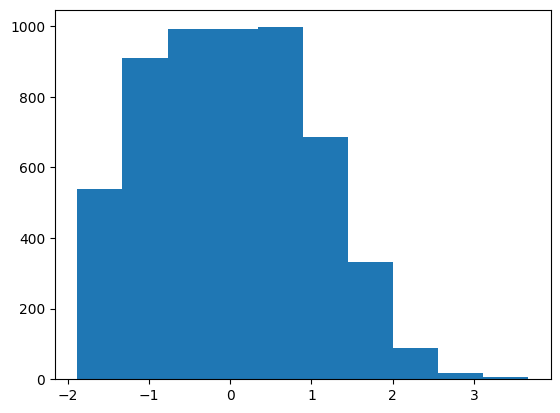

In [45]:
plt.hist(y_train)
plt.show()
# posunuly jsme to aby průměrný lék byl na nule

In [46]:
# snížení počtu příznaků
print(X_train.shape)
feature_select = VarianceThreshold(threshold=0.05)
X_train = feature_select.fit_transform(X_train)
X_validation = feature_select.transform(X_validation)
X_test = feature_select.transform(X_test)
print(X_train.shape)

(5562, 4096)
(5562, 220)


In [47]:
# mám jenom CPU
device = torch.device("cpu")
device

device(type='cpu')

In [48]:
# převede z numpy na pandas strukturu
X_train = torch.tensor(X_train, device=device).float()
X_test = torch.tensor(X_test, device=device).float()
X_validation = torch.tensor(X_validation, device=device).float()
y_train = torch.tensor(y_train, device=device).float()
y_test = torch.tensor(y_test, device=device).float()
y_validation = torch.tensor(y_validation, device=device).float()
X_train

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 1., 0., 0.],
        [0., 0., 0.,  ..., 0., 1., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 1., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [1., 0., 0.,  ..., 0., 0., 0.]])

In [49]:
# tohle poskládá ty datasety
from torch.utils.data import TensorDataset
train_dataset = TensorDataset(X_train, y_train)
validation_dataset = TensorDataset(X_validation, y_validation)

In [50]:
# nebudeme to tam dávat všechno najednou ale po dávkách (batch)
train_loader = torch.utils.data.DataLoader(dataset=train_dataset,
                                          batch_size=256,
                                          shuffle=True)
validation_loader = torch.utils.data.DataLoader(dataset=validation_dataset,
                                          batch_size=256,
                                          shuffle=False)

In [51]:
# definujeme jak naše sít bude vypadat
class Net(nn.Module):
    def __init__(self, input_size, hidden_size, dropout_rate, out_size):
        super(Net, self).__init__()
        # Three layers and a output layer
        self.fc1 = nn.Linear(input_size, hidden_size)  # 1st Full-Connected Layer
        self.fc15 = nn.Linear(hidden_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, hidden_size)
        self.fc_out = nn.Linear(hidden_size, out_size) # Output layer
        #Layer normalization for faster training
        self.ln1 = nn.LayerNorm(hidden_size)
        self.ln15 = nn.LayerNorm(hidden_size)
        self.ln2 = nn.LayerNorm(hidden_size)
        self.ln3 = nn.LayerNorm(hidden_size)
        #LeakyReLU will be used as the activation function
        self.activation = nn.LeakyReLU()
        #Dropout for regularization
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, x):# Forward pass: stacking each layer together
        # Fully connected =&amp;gt; Layer Norm =&amp;gt; LeakyReLU =&amp;gt; Dropout times 3
        out = self.fc1(x)
        out = self.ln1(out)
        out = self.activation(out)
        out = self.dropout(out)
        out = self.fc15(out)
        out = self.ln15(out)
        out = self.activation(out)
        out = self.dropout(out)
        out = self.fc2(out)
        out = self.ln2(out)
        out = self.activation(out)
        out = self.dropout(out)
        out = self.fc3(out)
        out = self.ln3(out)
        out = self.activation(out)
        out = self.dropout(out)
        #Final output layer
        out = self.fc_out(out)
        return out


In [52]:
# definujeme jednotlivé parametry té neuronky
input_size = X_train.size()[-1]     # The input size should fit our fingerprint size
hidden_size = 1024   # The size of the hidden layer
dropout_rate = 0.80    # The dropout rate
output_size = 1        # This is just a single task, so this will be one
learning_rate = 0.001  # The learning rate for the optimizer
model = Net(input_size, hidden_size, dropout_rate, output_size)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate) # adam -> způsob jak najít optimum


In [53]:
# samotné trnénovaní
model.train() #Ensure the network is in "train" mode with dropouts active
epochs = 100
for e in range(epochs):
    running_loss = 0
    for fps, labels in train_loader:
        # Training pass
        optimizer.zero_grad() # Initialize the gradients, which will be recorded during the forward pa

        output = model(fps) #Forward pass of the mini-batch
        loss = criterion(output, labels) #Computing the loss
        loss.backward() # calculate the backward pass
        optimizer.step() # Optimize the weights

        running_loss += loss.item()
    else:
        if e%10 == 0:
            validation_loss = torch.mean(( y_validation - model(X_validation) )**2).item()
            print("Epoch: %3i Training loss: %0.2F Validation loss: %0.2F"%(e,(running_loss/len(train_loader)), validation_loss))

Epoch:   0 Training loss: 1.46 Validation loss: 1.06
Epoch:  10 Training loss: 0.60 Validation loss: 0.58
Epoch:  20 Training loss: 0.48 Validation loss: 0.50
Epoch:  30 Training loss: 0.42 Validation loss: 0.49
Epoch:  40 Training loss: 0.38 Validation loss: 0.44
Epoch:  50 Training loss: 0.34 Validation loss: 0.41
Epoch:  60 Training loss: 0.33 Validation loss: 0.43
Epoch:  70 Training loss: 0.31 Validation loss: 0.41
Epoch:  80 Training loss: 0.30 Validation loss: 0.39
Epoch:  90 Training loss: 0.29 Validation loss: 0.42


In [54]:
# přepnutí na evaluaci aby nedošlo k vypinání vrstev
model.eval() #Switch to evaluation mode, where dropout is switched off
y_pred_train = model(X_train)
y_pred_validation = model(X_validation)
y_pred_test = model(X_test)

In [55]:
# výpočet MSE průměrný „trest“, který tvoje síť dostane za to, že se netrefila do správných výsledků.
print(torch.mean(( y_train - y_pred_train )**2).item())
print(torch.mean(( y_validation - y_pred_validation )**2).item())
print(torch.mean(( y_test - y_pred_test )**2).item())

0.18688328564167023
0.32189279794692993
0.380685418844223


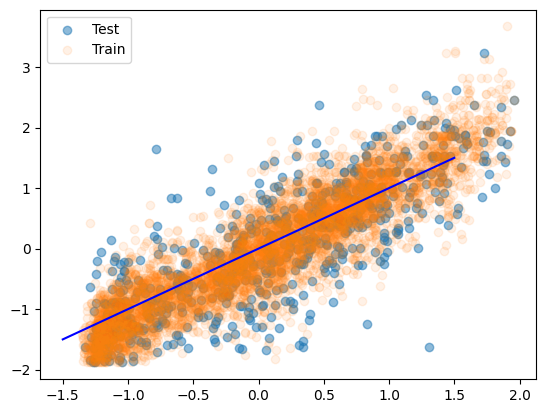

In [56]:
# beru ty chyby a kreslám z nich obrázek
def flatten(tensor):
    return tensor.cpu().detach().numpy().flatten()
plt.scatter(flatten(y_pred_test), flatten(y_test), alpha=0.5, label="Test")
plt.scatter(flatten(y_pred_train), flatten(y_train), alpha=0.1, label="Train")
plt.legend()
plt.plot([-1.5, 1.5], [-1.5,1.5], c="b")
# chci aby mi to leželo na té modré čáře

In [57]:
# funkce k ohodnocení posledních 10%
def predict_smiles(smiles):
    fp = mol2fp(Chem.MolFromSmiles(smiles)).reshape(1,-1)
    fp_filtered = feature_select.transform(fp)
    fp_tensor = torch.tensor(fp_filtered, device=device).float()
    prediction = model(fp_tensor)
    #return prediction.cpu().detach().numpy()
    pXC50 = scaler.inverse_transform(prediction.cpu().detach().numpy())
    return pXC50[0][0]

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

with torch.no_grad(): # vypne počítání gradientů, šetří to paměť při predikci
    y_pred_test_raw = model(X_test)

# 2. Musíme ty výsledky převést z "uhlazeného" formátu zpět na reálné pXC50
y_pred_test_real = scaler.inverse_transform(y_pred_test_raw.cpu().numpy())
y_test_real = scaler.inverse_transform(y_test.cpu().numpy())

# 3. Výpočet tvých tří oblíbených metrik
r2 = r2_score(y_test_real, y_pred_test_real)
mae = mean_absolute_error(y_test_real, y_pred_test_real)
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_test_real))

print("--- VÝSLEDKY NEURONOVÉ SÍTĚ NA TESTOVACÍCH DATECH (10 %) ---")
print(f"R2 skóre (úspěšnost): {r2:.4f}")# přesnost v %
print(f"MAE (průměrná chyba): {mae:.4f}")# v průměru se seknu o
print(f"RMSE (přísnější chyba): {rmse:.4f}")# přísnější přesnost více trestá velké chyby


--- VÝSLEDKY NEURONOVÉ SÍTĚ NA TESTOVACÍCH DATECH (10 %) ---
R2 skóre (úspěšnost): 0.6461
MAE (průměrná chyba): 0.5554
RMSE (přísnější chyba): 0.7246
